# Neural network for image classification


## Approach 1 - extract all the pixels


### Importing the libraries


In [1]:
import os
import zipfile

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from google.colab.patches import cv2_imshow

In [2]:
tf.__version__

'2.18.0'

### Extracting pixels from images


In [3]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
path = '/content/drive/MyDrive/Computer-Vision/Datasets/homer_bart_1.zip'
zip_object = zipfile.ZipFile(file=path, mode='r')
zip_object.extractall('./')
zip_object.close()

In [5]:
directory = '/content/homer_bart_1'
files = [os.path.join(directory, f) for f in sorted(os.listdir(directory))]
print(files)

['/content/homer_bart_1/.DS_Store', '/content/homer_bart_1/bart1.bmp', '/content/homer_bart_1/bart10.bmp', '/content/homer_bart_1/bart100.bmp', '/content/homer_bart_1/bart101.bmp', '/content/homer_bart_1/bart102.bmp', '/content/homer_bart_1/bart103.bmp', '/content/homer_bart_1/bart104.bmp', '/content/homer_bart_1/bart105.bmp', '/content/homer_bart_1/bart106.bmp', '/content/homer_bart_1/bart108.bmp', '/content/homer_bart_1/bart109.bmp', '/content/homer_bart_1/bart11.bmp', '/content/homer_bart_1/bart110.bmp', '/content/homer_bart_1/bart111.bmp', '/content/homer_bart_1/bart112.bmp', '/content/homer_bart_1/bart113.bmp', '/content/homer_bart_1/bart114.bmp', '/content/homer_bart_1/bart115.bmp', '/content/homer_bart_1/bart116.bmp', '/content/homer_bart_1/bart117.bmp', '/content/homer_bart_1/bart118.bmp', '/content/homer_bart_1/bart119.bmp', '/content/homer_bart_1/bart12.bmp', '/content/homer_bart_1/bart120.bmp', '/content/homer_bart_1/bart121.bmp', '/content/homer_bart_1/bart122.bmp', '/conte

In [6]:
type(files)

list

In [7]:
height, width = 128, 128

In [8]:
images = []
classes = []

In [9]:
for image_path in files:
    try:
        image = cv2.imread(image_path)
        (H, W) = image.shape[:2]
    except:
        continue

    image = cv2.resize(image, (width, height))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    cv2_imshow(image)

    image = image.ravel()
    print(image.shape)

    images.append(image)

    image_name = os.path.basename(os.path.normpath(image_path))
    if image_name.startswith('b'):
        class_name = 0
    else:
        class_name = 1

    classes.append(class_name)
    print(class_name)

Output hidden; open in https://colab.research.google.com to view.

In [10]:
images

[array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([254, 254, 254, ..., 254, 254, 254], dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([255, 255, 255, ..., 128, 123, 124], dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([254, 254, 254, ..., 254, 254, 254], dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([255, 2

In [11]:
print(classes)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [12]:
type(images), type(classes)

(list, list)

In [13]:
X = np.asarray(images)
y = np.asarray(classes)

In [14]:
type(X), type(y)

(numpy.ndarray, numpy.ndarray)

In [15]:
X.shape  # 128 * 128

(269, 16384)

In [16]:
y.shape

(269,)

In [17]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1])

In [18]:
X[0].shape

(16384,)

In [19]:
cv2_imshow(X[0])

In [20]:
X[0].reshape(width, height).shape

(128, 128)

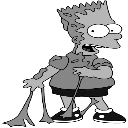

In [21]:
cv2_imshow(X[0].reshape(width, height))

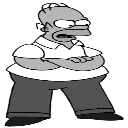

In [22]:
cv2_imshow(X[200].reshape(width, height))

<ipython-input-23-7ebb084f2926>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette={'0': "skyblue", '1': "salmon"})


<Axes: ylabel='count'>

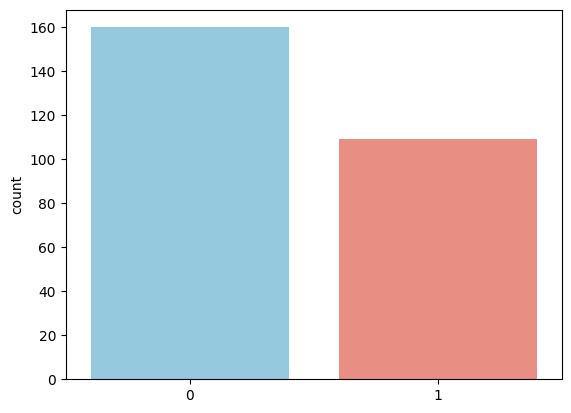

In [23]:
sns.countplot(x=y, palette={'0': "skyblue", '1': "salmon"})

In [24]:
np.unique(y, return_counts=True)

(array([0, 1]), array([160, 109]))

### Normalizing the data


In [25]:
X[0].max(), X[0].min()

(np.uint8(255), np.uint8(0))

In [26]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X = scaler.fit_transform(X)

In [27]:
X[0].max(), X[0].min()

(np.float64(1.0000000000000002), np.float64(0.0))

In [28]:
X[1]

array([0.9947644 , 0.99479167, 0.99479167, ..., 0.99559471, 0.99595142,
       0.9950495 ])

### Train and test set


In [29]:
from sklearn.model_selection import train_test_split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1)

In [31]:
X_train.shape, y_train.shape

((215, 16384), (215,))

In [32]:
X_test.shape, y_test.shape

((54, 16384), (54,))

### Building and training the neural network


In [33]:
(16384 + 2) / 2

8193.0

In [34]:
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Sequential

# 16384 -> 8193 -> 8193 -> 1
network1 = Sequential()
network1.add(Input(shape=(16384,)))
network1.add(Dense(units=8193, activation='relu'))
network1.add(Dense(units=8193, activation='relu'))
network1.add(Dense(units=1, activation='sigmoid'))

In [35]:
network1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8193)           │   134,242,305 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8193)           │    67,133,442 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201,383,941 (768.22 MB)

 Trainable params: 201,383,941 (768.22 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.optimizers import Adam

# https://keras.io/api/optimizers/
# https://keras.io/api/losses/

network1.compile(optimizer=Adam(), loss=BinaryCrossentropy(),
                 metrics=['accuracy'])

In [37]:
history = network1.fit(X_train, y_train, epochs=20)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 764ms/step - accuracy: 0.5359 - loss: 131.2321
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4763 - loss: 6.1019
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5700 - loss: 10.5397
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5733 - loss: 4.0300
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6224 - loss: 0.7390
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6079 - loss: 0.6636
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7260 - loss: 0.5713
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6172 - loss: 0.6589
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7532 - loss: 0.6078
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7503 - loss: 0.5272
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6860 - loss: 0.5812
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7226 - loss: 0.5

### Evaluating the neural network


In [38]:
history.history.keys()

dict_keys(['accuracy', 'loss'])

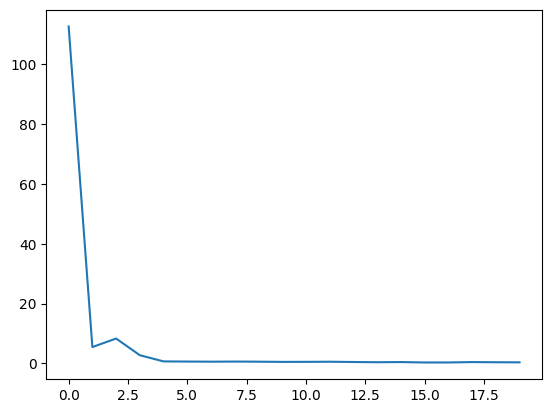

In [39]:
plt.plot(history.history['loss'])

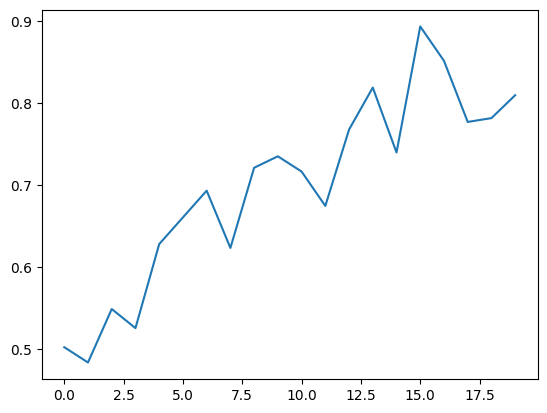

In [40]:
plt.plot(history.history['accuracy'])

In [41]:
X_test.shape

(54, 16384)

In [42]:
predictions = network1.predict(X_test)
predictions

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


array([[0.1256737 ],
       [0.9179259 ],
       [0.21750355],
       [0.13811463],
       [0.72467095],
       [0.20372349],
       [0.8164121 ],
       [0.7293299 ],
       [0.51241344],
       [0.7017685 ],
       [0.27510068],
       [0.9916437 ],
       [0.6483835 ],
       [0.30901924],
       [0.34457985],
       [0.09376047],
       [0.18420403],
       [0.43673125],
       [0.14831157],
       [0.19617599],
       [0.10625466],
       [0.5392338 ],
       [0.12634933],
       [0.1736118 ],
       [0.19254272],
       [0.41960987],
       [0.10579053],
       [0.14182673],
       [0.3419687 ],
       [0.8792221 ],
       [0.5613512 ],
       [0.96032196],
       [0.3942045 ],
       [0.12238036],
       [0.98397416],
       [0.16686197],
       [0.38155523],
       [0.12613548],
       [0.36439937],
       [0.1545223 ],
       [0.7638159 ],
       [0.68490505],
       [0.1604538 ],
       [0.14824277],
       [0.1595754 ],
       [0.4591163 ],
       [0.7771809 ],
       [0.221

In [43]:
# 0 False - Bart
# 1 True  - Homer

In [44]:
predictions = (predictions > 0.5)
predictions

array([[False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [ True]])

In [45]:
y_test

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 1])

In [46]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, predictions)

0.7037037037037037

In [48]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)
cm

array([[23,  5],
       [11, 15]])

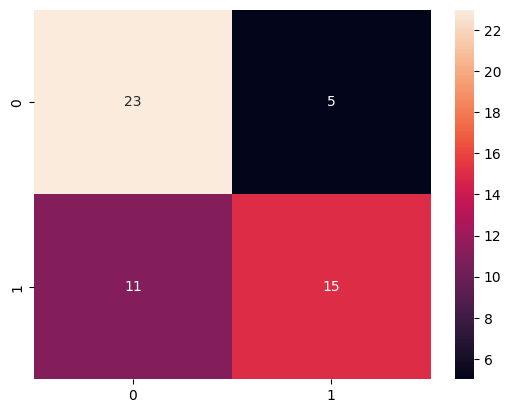

In [49]:
sns.heatmap(cm, annot=True)

In [50]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.68      0.82      0.74        28
           1       0.75      0.58      0.65        26

    accuracy                           0.70        54
   macro avg       0.71      0.70      0.70        54
weighted avg       0.71      0.70      0.70        54



### Saving and loading the network


In [54]:
model_json = network1.to_json()
with open('network1.json', 'w') as json_file:
    json_file.write(model_json)

In [60]:
from tensorflow.keras.models import save_model

save_model(network1, 'weights1.hdf5')

In [61]:
with open('network1.json') as json_file:
    json_saved_model = json_file.read()
json_saved_model

'{"module": "keras", "class_name": "Sequential", "config": {"name": "sequential", "trainable": true, "dtype": {"module": "keras", "class_name": "DTypePolicy", "config": {"name": "float32"}, "registered_name": null}, "layers": [{"module": "keras.layers", "class_name": "InputLayer", "config": {"batch_shape": [null, 16384], "dtype": "float32", "sparse": false, "name": "input_layer"}, "registered_name": null}, {"module": "keras.layers", "class_name": "Dense", "config": {"name": "dense", "trainable": true, "dtype": {"module": "keras", "class_name": "DTypePolicy", "config": {"name": "float32"}, "registered_name": null}, "units": 8193, "activation": "relu", "use_bias": true, "kernel_initializer": {"module": "keras.initializers", "class_name": "GlorotUniform", "config": {"seed": null}, "registered_name": null}, "bias_initializer": {"module": "keras.initializers", "class_name": "Zeros", "config": {}, "registered_name": null}, "kernel_regularizer": null, "bias_regularizer": null, "kernel_constra

In [63]:
network1_loaded = tf.keras.models.model_from_json(json_saved_model)
network1_loaded.load_weights('/content/weights1.hdf5')
network1_loaded.compile(
    loss=BinaryCrossentropy(),
    optimizer=Adam(),
    metrics=['accuracy']
)

In [64]:
network1_loaded.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8193)           │   134,242,305 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8193)           │    67,133,442 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201,383,941 (768.22 MB)

 Trainable params: 201,383,941 (768.22 MB)

 Non-trainable params: 0 (0.00 B)

### Classifying one single image


In [70]:
X_test[34].shape

(16384,)

In [71]:
test_image = X_test[34]
test_image = scaler.inverse_transform(test_image.reshape(1, -1))

In [72]:
test_image

array([[255., 255., 255., ..., 255., 255., 255.]])

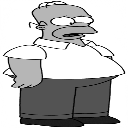

In [73]:
cv2_imshow(test_image.reshape(width, height))

In [74]:
network1_loaded.predict(test_image)[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


np.float32(1.0)

In [75]:
if network1_loaded.predict(test_image)[0][0] < 0.5:
    print('Bart')
else:
    print('Homer')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Homer


## Approach 2 - feature extraction


### Feature extractor


In [76]:
files = [os.path.join(directory, f) for f in sorted(os.listdir(directory))]
print(files)

['/content/homer_bart_1/.DS_Store', '/content/homer_bart_1/bart1.bmp', '/content/homer_bart_1/bart10.bmp', '/content/homer_bart_1/bart100.bmp', '/content/homer_bart_1/bart101.bmp', '/content/homer_bart_1/bart102.bmp', '/content/homer_bart_1/bart103.bmp', '/content/homer_bart_1/bart104.bmp', '/content/homer_bart_1/bart105.bmp', '/content/homer_bart_1/bart106.bmp', '/content/homer_bart_1/bart108.bmp', '/content/homer_bart_1/bart109.bmp', '/content/homer_bart_1/bart11.bmp', '/content/homer_bart_1/bart110.bmp', '/content/homer_bart_1/bart111.bmp', '/content/homer_bart_1/bart112.bmp', '/content/homer_bart_1/bart113.bmp', '/content/homer_bart_1/bart114.bmp', '/content/homer_bart_1/bart115.bmp', '/content/homer_bart_1/bart116.bmp', '/content/homer_bart_1/bart117.bmp', '/content/homer_bart_1/bart118.bmp', '/content/homer_bart_1/bart119.bmp', '/content/homer_bart_1/bart12.bmp', '/content/homer_bart_1/bart120.bmp', '/content/homer_bart_1/bart121.bmp', '/content/homer_bart_1/bart122.bmp', '/conte

In [77]:
export = 'mouth,pants,shoes,tshirt,shorts,sneakers,class\n'

In [78]:
show_images = False
features = []

In [79]:
100 * 200

20000

In [80]:
(2000 / 20000) * 100

10.0

In [81]:
100 / 2

50.0

In [82]:
for image_path in files:
    # print(image_path)
    try:
        original_image = cv2.imread(image_path)
        (H, W) = original_image.shape[:2]
    except:
        continue

    image = original_image.copy()
    image_features = []
    mouth = pants = shoes = 0
    tshirt = shorts = sneakers = 0

    image_name = os.path.basename(os.path.normpath(image_path))

    if image_name.startswith('b'):
        class_name = 0
    else:
        class_name = 1

    for height in range(0, H):
        for width in range(0, W):
            blue = image.item(height, width, 0)
            green = image.item(height, width, 1)
            red = image.item(height, width, 2)

            # Homer - brown mouth
            if (blue >= 95 and blue <= 140 and green >= 160 and green <= 185 and red >= 175 and red <= 200):
                image[height, width] = [0, 255, 255]
                mouth += 1

            # Homer - blue pants
            if (blue >= 150 and blue <= 180 and green >= 98 and green <= 120 and red >= 0 and red <= 90):
                image[height, width] = [0, 255, 255]
                pants += 1

            # Homer - gray shoes
            if height > (H / 2):
                if (blue >= 25 and blue <= 45 and green >= 25 and green <= 45 and red >= 25 and red <= 45):
                    image[height, width] = [0, 255, 255]
                    shoes += 1

            # Bart - orange t-shirt
            if (blue >= 11 and blue <= 22 and green >= 85 and green <= 105 and red >= 240 and red <= 255):
                image[height, width] = [0, 255, 128]
                tshirt += 1

            # Bart - blue shorts
            if (blue >= 125 and blue <= 170 and green >= 0 and green <= 12 and red >= 0 and red <= 20):
                image[height, width] = [0, 255, 128]
                shorts += 1

            # Bart - blue sneakers
            if height > (H / 2):
                if (blue >= 125 and blue <= 170 and green >= 0 and green <= 12 and red >= 0 and red <= 20):
                    image[height, width] = [0, 255, 128]
                    sneakers += 1

    mouth = round((mouth / (H * W)) * 100, 9)
    pants = round((pants / (H * W)) * 100, 9)
    shoes = round((shoes / (H * W)) * 100, 9)

    tshirt = round((tshirt / (H * W)) * 100, 9)
    shorts = round((shorts / (H * W)) * 100, 9)
    sneakers = round((sneakers / (H * W)) * 100, 9)

    image_features.append(mouth)
    image_features.append(pants)
    image_features.append(shoes)
    image_features.append(tshirt)
    image_features.append(shorts)
    image_features.append(sneakers)
    image_features.append(class_name)

    features.append(image_features)

    # print('Homer mouth: %s - Homer pants: %s - Homer shoes: %s' % (image_features[0], image_features[1], image_features[2]))
    # print('Bart t-shirt: %s - Bart shorts: %s - Bart sneakers: %s' % (image_features[3], image_features[4], image_features[5]))

    f = (",".join([str(item) for item in image_features]))
    export += f + '\n'

    if show_images == True:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
        fig, im = plt.subplots(1, 2)
        im[0].axis('off')
        im[0].imshow(original_image)
        im[1].axis('off')
        im[1].imshow(image)
        plt.show()

In [83]:
export

'mouth,pants,shoes,tshirt,shorts,sneakers,class\n0.0,0.0,0.114799225,6.886101887,3.495204355,3.495204355,0\n0.0,0.0,0.11007847,5.004901113,3.183888705,3.183888705,0\n0.0,0.0,0.182518631,5.264620437,5.029682961,5.029682961,0\n0.0,0.480168257,0.080028043,0.0,0.0,0.0,0\n0.0,0.0,0.029707562,8.978929368,3.459119497,3.459119497,0\n0.0,0.0,0.053304904,6.75432362,0.948827292,0.948827292,0\n0.249585206,0.0,0.019853369,9.693407263,4.104683977,4.104683977,0\n0.0,0.0,0.181208054,0.0,0.0,0.0,0\n0.0,0.0,0.148868778,0.0,0.0,0.0,0\n0.0,0.0,0.114762211,9.594752524,7.522715548,7.522715548,0\n0.0,0.0,0.138655462,0.0,0.0,0.0,0\n0.0,0.0,0.02400947,19.545383481,0.0,0.0,0\n0.00307645,0.0,0.0,6.495154592,5.599138594,5.599138594,0\n0.001317263,0.0,0.087817515,0.0,0.0,0.0,0\n0.0,0.0,0.032184591,8.395721925,0.0,0.0,0\n0.02105732,0.0,0.008503918,8.915750471,0.0,0.0,0\n0.0,0.0,0.081055114,11.095816228,4.525111363,4.525111363,0\n0.0,0.0,0.08757526,10.443349754,3.183296307,3.183296307,0\n0.0,0.0,0.043806812,9.497408

In [84]:
with open('features.csv', 'w') as file:
    for l in export:
        file.write(l)
file.closed

True

In [85]:
dataset = pd.read_csv('features.csv')
dataset

,mouth,pants,shoes,tshirt,shorts,sneakers,class
0,0.000000,0.000000,0.114799,6.886102,3.495204,3.495204,0
1,0.000000,0.000000,0.110078,5.004901,3.183889,3.183889,0
2,0.000000,0.000000,0.182519,5.264620,5.029683,5.029683,0
3,0.000000,0.480168,0.080028,0.000000,0.000000,0.000000,0
4,0.000000,0.000000,0.029708,8.978929,3.459119,3.459119,0
...,...,...,...,...,...,...,...
264,6.485412,0.000000,0.171985,0.000000,0.000000,0.000000,1
265,0.000000,0.000000,0.161637,0.000000,0.000000,0.000000,1
266,4.264975,0.000000,0.329940,0.000000,0.000000,0.000000,1
267,1.429133,0.000000,0.034559,0.000000,0.000000,0.000000,1


### Train and test sets


In [86]:
X = dataset.iloc[:, 0:6].values
X

array([[ 0.        ,  0.        ,  0.11479923,  6.88610189,  3.49520435,
         3.49520435],
       [ 0.        ,  0.        ,  0.11007847,  5.00490111,  3.18388871,
         3.18388871],
       [ 0.        ,  0.        ,  0.18251863,  5.26462044,  5.02968296,
         5.02968296],
       ...,
       [ 4.26497522,  0.        ,  0.32993967,  0.        ,  0.        ,
         0.        ],
       [ 1.42913348,  0.        ,  0.03455866,  0.        ,  0.        ,
         0.        ],
       [ 0.853902  , 13.74424774,  0.16177802,  0.        ,  0.        ,
         0.        ]])

In [87]:
y = dataset.iloc[:, 6].values
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1])

In [88]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1)

In [89]:
X_train.shape, y_train.shape

((215, 6), (215,))

In [90]:
X_test.shape, y_test.shape

((54, 6), (54,))

### Building and training the neural network


In [91]:
(6 + 2) / 2

4.0

In [92]:
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Sequential

# 6 -> 4 -> 4 -> 4 -> 1
network2 = Sequential()
network2.add(Input(shape=(6,)))
network2.add(Dense(units=4, activation='relu'))
network2.add(Dense(units=4, activation='relu'))
network2.add(Dense(units=4, activation='relu'))
network2.add(Dense(units=1, activation='sigmoid'))

In [93]:
network2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 4)              │            28 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73 (292.00 B)

 Trainable params: 73 (292.00 B)

 Non-trainable params: 0 (0.00 B)

In [94]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

network2.compile(
    optimizer=Adam(),
    loss=BinaryCrossentropy(),
    metrics=['accuracy']
)

In [95]:
history = network2.fit(X_train, y_train, epochs=30)

Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 217ms/step - accuracy: 0.4642 - loss: 0.7223
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4804 - loss: 0.7035 
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5033 - loss: 0.6889 
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4728 - loss: 0.6824 
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4644 - loss: 0.6787 
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4907 - loss: 0.6649 
Epoch 7/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5630 - loss: 0.6597 
Epoch 8/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6462 - loss: 0.6486 
Epoch 9/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6926 - loss: 0.6323 
Epoch 10/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7248 - loss: 0.6283 
Epoch 11/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7215 - loss: 0.6161 
Epoch 12/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7397 - loss: 0.6078 


### Evaluating the neural network


In [96]:
history.history.keys()

dict_keys(['accuracy', 'loss'])

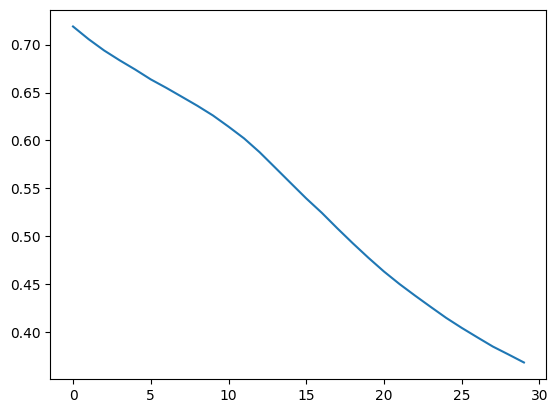

In [97]:
plt.plot(history.history['loss'])

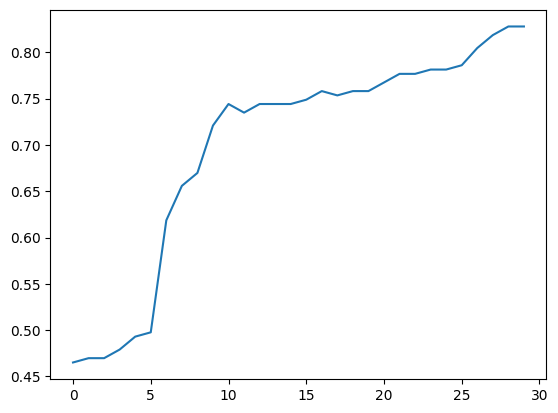

In [98]:
plt.plot(history.history['accuracy'])

In [99]:
X_test.shape

(54, 6)

In [100]:
predictions = network2.predict(X_test)
predictions

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 305ms/step


array([[0.09094422],
       [0.69415754],
       [0.30103117],
       [0.42397472],
       [0.14437668],
       [0.71993893],
       [0.00189345],
       [0.25517115],
       [0.16966914],
       [0.16644578],
       [0.47850725],
       [0.9584341 ],
       [0.5235163 ],
       [0.0435781 ],
       [0.43251333],
       [0.94469136],
       [0.4521721 ],
       [0.8247179 ],
       [0.42530334],
       [0.45345464],
       [0.47625658],
       [0.8678918 ],
       [0.67189765],
       [0.06437559],
       [0.00382371],
       [0.91067797],
       [0.4040538 ],
       [0.3841411 ],
       [0.7327304 ],
       [0.9219196 ],
       [0.6551543 ],
       [0.97126096],
       [0.9219866 ],
       [0.43697414],
       [0.97588545],
       [0.66025704],
       [0.14054938],
       [0.08585634],
       [0.42869475],
       [0.2946378 ],
       [0.6663873 ],
       [0.4416169 ],
       [0.21128722],
       [0.13993202],
       [0.12090155],
       [0.91563857],
       [0.5177337 ],
       [0.407

In [101]:
predictions = (predictions > 0.5)
predictions

array([[False],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [ True]])

In [102]:
y_test

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 1])

In [103]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, predictions)

0.9074074074074074

In [104]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)
cm

array([[27,  1],
       [ 4, 22]])

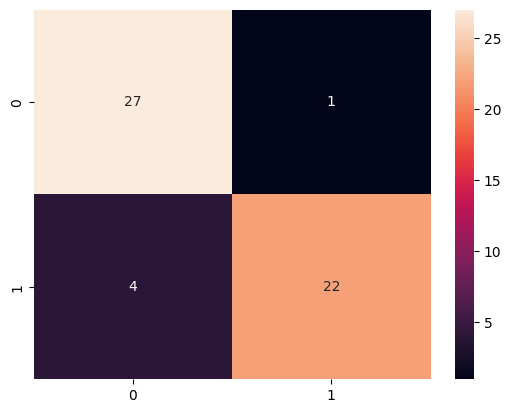

In [105]:
sns.heatmap(cm, annot=True)

In [106]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.87      0.96      0.92        28
           1       0.96      0.85      0.90        26

    accuracy                           0.91        54
   macro avg       0.91      0.91      0.91        54
weighted avg       0.91      0.91      0.91        54



### Saving, loading and classifying one single image


In [107]:
model_json = network2.to_json()
with open('network2.json', 'w') as json_file:
    json_file.write(model_json)

In [112]:
from keras.models import save_model

save_model(network2, '/content/weights2.hdf5')

In [109]:
with open('network2.json', 'r') as json_file:
    json_saved_model = json_file.read()
json_saved_model

'{"module": "keras", "class_name": "Sequential", "config": {"name": "sequential_1", "trainable": true, "dtype": {"module": "keras", "class_name": "DTypePolicy", "config": {"name": "float32"}, "registered_name": null}, "layers": [{"module": "keras.layers", "class_name": "InputLayer", "config": {"batch_shape": [null, 6], "dtype": "float32", "sparse": false, "name": "input_layer_1"}, "registered_name": null}, {"module": "keras.layers", "class_name": "Dense", "config": {"name": "dense_3", "trainable": true, "dtype": {"module": "keras", "class_name": "DTypePolicy", "config": {"name": "float32"}, "registered_name": null}, "units": 4, "activation": "relu", "use_bias": true, "kernel_initializer": {"module": "keras.initializers", "class_name": "GlorotUniform", "config": {"seed": null}, "registered_name": null}, "bias_initializer": {"module": "keras.initializers", "class_name": "Zeros", "config": {}, "registered_name": null}, "kernel_regularizer": null, "bias_regularizer": null, "kernel_constrai

In [116]:
network2_loaded = tf.keras.models.model_from_json(json_saved_model)
network2_loaded.load_weights('/content/weights2.hdf5')
network2_loaded.compile(
    loss=BinaryCrossentropy(),
    optimizer=Adam(),
    metrics=['accuracy']
)

In [117]:
network2_loaded.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 4)              │            28 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73 (292.00 B)

 Trainable params: 73 (292.00 B)

 Non-trainable params: 0 (0.00 B)

In [118]:
test_image = X_test[0]
test_image

array([3.07645000e-03, 0.00000000e+00, 0.00000000e+00, 6.49515459e+00,
       5.59913859e+00, 5.59913859e+00])

In [119]:
test_image.shape

(6,)

In [120]:
test_image = test_image.reshape(1, -1)
test_image.shape

(1, 6)

In [121]:
network2_loaded.predict(test_image)[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


np.float32(0.09078699)

In [122]:
if network2_loaded.predict(test_image)[0][0] < 0.5:
    print('Bart')
else:
    print('Homer')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Bart
